# Application Programming Interface

Det er mulig aksessere en webside eller database gjennom et Application Programming Interface (API). Deretter foreta et API-kall med en forespørsel, eller en 'query'.

Et API muliggjør kommunikasjon mellom servere.

### Fordelen med API

Med API kan du lage spørringer som henter oppdaterte tall.

API-et gir dynamiske data.

API gjør det lettere å hente tall for videre analyse.

Det er mer fleksibelt og mer avansert enn å laste ned data fra et brukergrensensittet bestemt av den som har laget nettsiden.

Det er lettere å tilpasse akkurat de data du trenger, og så lenge det er kontakt mellom deg (klient) og nettstedet (server) har du tilgang til dataene uten å måtte lagre lokalt.

### REST API

En Representational State Transfer ([REST](https://en.wikipedia.org/wiki/REST)) er en programvare-arkitektur som definerer kommunikasjon i et nettverk mellom *client* og *server* i et nettverk. Kommunikasjonen skjer gjennom et regelverk; hypertekstoverføringsprotokoll, Hyper Text Transfer Protocol (HTTP).

Forespørsler skjer gjennom `request` biblioteket som lar deg benytte en hypertekstoverføringsprotokoll i python miljøet.

Pythons [requests](https://pypi.org/project/requests/) er et brukervennlig bibliotek som 
tilgjengelig for intallasjon på Pypi:

$ python -m pip install requests

Metoden `.get()` brukes til en HTTP GET-forespørsel fra nettleseren din (klienten) til serveren gjennom nettstedets URL-adresse. Nettstedet gir et respons gjennom en statuskode. Kode 200 betyr at siden eksisterer og fungerer. Ethvert nettsted vi prøver å aksessere vil gi oss en statuskode:

In [ ]:
import requests
api_url = 'https://usn.no'
response = requests.get(api_url)
print(response.status_code)

Satus kode 200 vil si at siden eksisterer og vi har kontakt. Alt ligger til rette for å dele data mellom deg (klienten) og nettstedet (server).

### Javascript Object Notation

Standard formatet for overføring av tekst i nettverk er Javascript Object Notation (JSON). Det er lett å forstå både for mennesker og maskiner og er filformatet som brukes i databaser og API. JSON lagrer data i nøkkel-verdi par, ikke ulikt python dictionary, som en samling dataelementer av forskjellig datatype, der datene indekseres med nøkkel i form av en tekststreng. Se ressursiden til *Python for realfag* [TechTeach](https://techteach.no/python/), oppgave [3.11](https://techteach.no/python/files/pannekaker.py).

JSON nøkkel er alltid et string objekt, innelukket i en krøllparantes og alltid med dobbelt anførselstegn `"`. Verdiene som korresponderer til nøkkelen kan være hvilken som helst [data type](https://www.geeksforgeeks.org/python/python-data-types/), nøstet JSON, eller andre sekvens data.


For å lese JSON i python bruker vi python-bibliotekt [`json`](https://www.geeksforgeeks.org/python/python-json/)

In [ ]:
import json
s = '{"language":"Python", "version": 3.11}'
d = json.loads(s)
print(d)

json biblioteket muliggjør konvertering til [python dictionary](https://www.geeksforgeeks.org/python/difference-between-json-and-dictionary-in-python/):

In [ ]:
import json

emp = '{"id":"09", "name": "Nitin", "department":"Finance"}'
print("This is JSON", type(emp), emp)

print("Now convert from JSON to Python")
d = json.loads(emp)
print("Converted to Python", type(d))
print(d)

### API endepunkt

Også når vi aksesserer apiet får vi gyldig status, fordi vi klarer å oppnå kontakt med nettstedet. Men vi får feilmelidng fordi nettstedet ikke inneholder `.json()`. Det er derimor en html side. Selv om vi skriver inn 
```python
"https://data.ssb.no/api"
```
har vi ikke fått kontakt med datatabeller i `.json` fil men med en `html`-side.

In [ ]:
import requests
api_url = "https://data.ssb.no/api"
response = requests.get(api_url)
print(response.status_code)

import traceback

response = requests.get("https://data.ssb.no/api")

try:
    data = response.json()
except Exception:
    print('Feilemelding:',traceback.format_exc().splitlines()[-1])

print(response.headers["Content-Type"]) 

For å få kontakt med den informasjonen API-et inneholder må vi nå endepunktsURL (endpoint). Nettstedet [Data.norge.no](https://data.norge.no/nb/about) har oversikt over data fra norsk offentlig sektor, med en egen datakatalog over API-er

In [ ]:
# TEST CELL
from IPython.display import Image

Image("../images/dataNorge.png", width=1500, height=1400)

Alle API-ene i katalogen følger standard for beskrivelse av datasett, datatjenester og datakataloger ([DCAT-AP-NO](https://data.norge.no/specification/dcat-ap-no)) der endepunktsURL er standardinformasjon.
```note
En datatjeneste

SKAL alltid beskrives med opplysninger om utgiveren av datatjenesten og kontaktpunkt, samt tittel og endepunktsURL til datatjenesten
```

In [ ]:
# TEST CELL
from IPython.display import Image

Image("../images/DCAT-AP-NO.png", width=1000, height=800)

Et søk etter [statistikkbanken](https://data.norge.no/nb/data-services/4c525f0a-f10d-3bcc-a67e-ee3fbbfd6ccc/api-lag-egne-datasett-fra-ssbs-statistikkbank-pxwebapi?tab=overview) her gir endepunktsURL til datatabeller

In [ ]:
# TEST CELL
from IPython.display import Image

Image("../images/SSB_endpoint.png", width=1500, height=1400)

### Open API

[OpenAPI](https://swagger.io/docs/specification/v3_0/about/) er en standardisert beskrivelse av et API, som kommer med en egen [dokumentasjon](https://swagger.io/specification/v3.2/#openapi-description-structure) Swagger UI er et verktøy som viser denne beskrivelsen som en interaktiv nettside. På [SSB's swagger](https://data.ssb.no/api/pxwebapi/v2/index.html) kan man teste ut forskjellige `.get`forespørsler. En blank forespørsel gir endpunktsURL for alle tabeller.
```python
https://data.ssb.no/api/pxwebapi/v2/tables
```


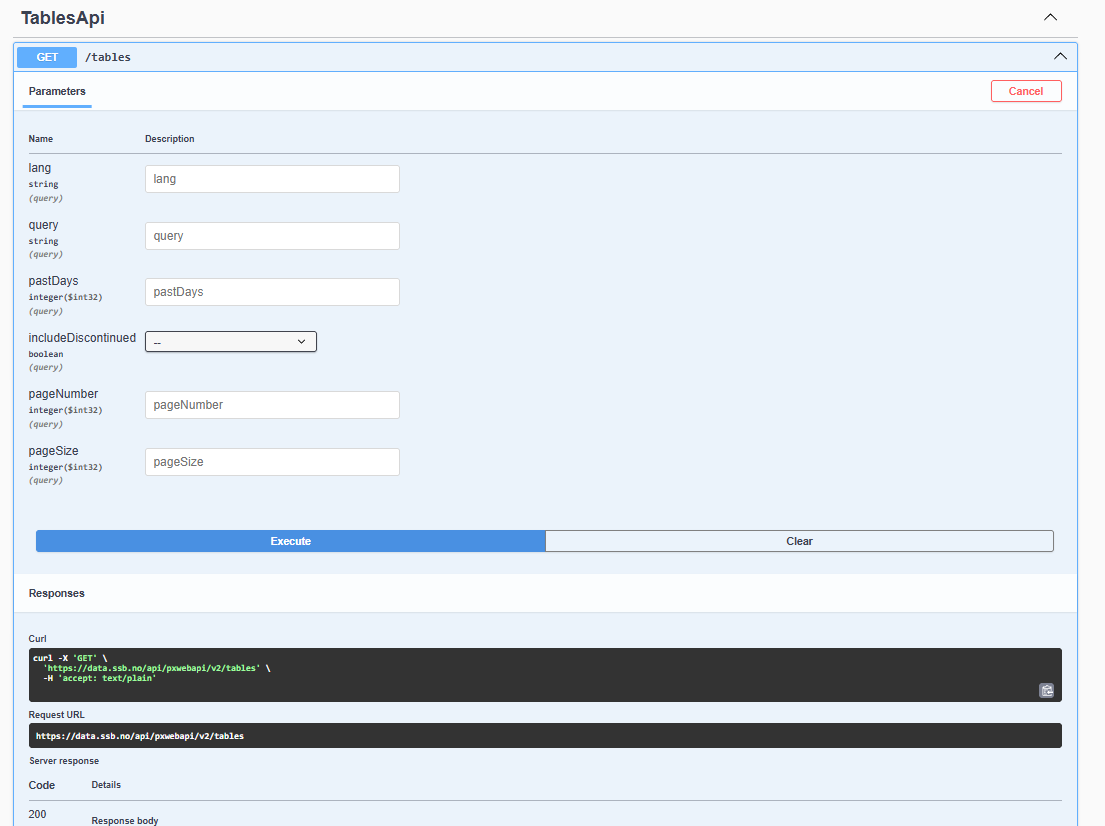

In [1]:
from IPython.display import Image

Image("../images/swagger.png", width=1500, height=1400)

In [15]:
import requests
api_url = 'https://data.ssb.no/api/v0/no/table/08307'

query = {
    "query": [
    {
        "code": "ContentsCode",
        "selection": {
            "filter": "item",
            "values": ["VindKraft", "Solkraft"]
        }
    },
    {
        "code": "Tid",
        "selection": {
            "filter": "item",
            "values": ['2021', '2022', '2023', '2024', '2025']
        }
    }
    ],
    "response":{
        "format": "json-stat2"
    }
}

response = requests.get(api_url, json=query)

#print(response.status_code)
data = response.json()
print(data)


JSONDecodeError: Expecting value: line 2 column 1 (char 1)

In [12]:
from pyjstat import pyjstat

dataset = pyjstat.Dataset.read(response.text)

df = dataset.write('dataframe')

print(df)

AttributeError: 'str' object has no attribute 'get'

Med pandas kan man få ut tabellen som en lesbar 'dataframe', som i dette tilfellet er tabellen over tabeller:

In [ ]:
import requests
import pandas as pd
api_url = 'https://data.ssb.no/api/v0/no/table'
response = requests.get(api_url)

df = pd.DataFrame(response.json())

print(response.json())
print(df)

In [ ]:
import requests
api_url = 'https://data.ssb.no/api/v0/no/table/08307'
response = requests.get(api_url)

print(response.json())

Metoden .json() gir oss innholdet i repsonsen. Dette er metadata som gir data om dataen.

In [ ]:
metadata = reponse.json()
print(metadata)

### Lager spørring (query)

Vi definerer en spørring `query` i form av en liste ( [ ] ) og bestemmer hvordan vi vil ha svaret `response` i form av en dictionary ( { } ). 




Biblioteket pyjstat lager om til `dataframe`, som vi kan burke DateTimeIndex på.

In [ ]:
df

In [ ]:
import matplotlib.pyplot as plt
df.plot()

I metadataen ser vi verider 

In [ ]:
type(metadata)

In [ ]:
print(list(metadata.keys()))

In [ ]:
type(metadata['title'])

In [ ]:
type(metadata['variables'])

In [ ]:
print(metadata["variables"][0])
print(metadata["variables"][1])

In [ ]:
print(metadata["variables"][0].keys())
print(metadata["variables"][1].keys())

In [ ]:
for var in metadata["variables"]:
    print(f"\nKode: {var['code']}")
    print(f"Tekst: {var['text']}")
    print(f"Antall verdier: {len(var['values'])}")

In [ ]:
filtre = {
    var["code"]: var["values"]
    for var in metadata["variables"]
    if var["code"] in ["ContentsCode", "Tid"]
}

print(filtre)